In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Reshape,
    LeakyReLU,
    Input
)
from tensorflow.keras.optimizers import Adam


In [ ]:
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

In [ ]:
X_train = X_train.astype("float32")
X_train = (X_train - 127.5) / 127.5


In [ ]:
X_train = np.expand_dims(X_train, axis=-1)

img_shape = (28, 28, 1)
latent_dim = 100

print("Training Images Shape:", X_train.shape)


Training Images Shape: (60000, 28, 28, 1)


In [ ]:
def build_generator():

    model = Sequential([
        Input(shape=(latent_dim,)),

        Dense(256),
        LeakyReLU(negative_slope=0.2),

        Dense(512),
        LeakyReLU(negative_slope=0.2),

        Dense(1024),
        LeakyReLU(negative_slope=0.2),

        Dense(784, activation="tanh"),

        Reshape(img_shape)
    ])

    return model



In [ ]:
def build_discriminator():

    model = Sequential([
        Input(shape=img_shape),

        Flatten(),

        Dense(512),
        LeakyReLU(negative_slope=0.2),

        Dense(256),
        LeakyReLU(negative_slope=0.2),

        Dense(1, activation="sigmoid")
    ])

    return model


In [ ]:
generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.0002, beta_1=0.5),
    metrics=["accuracy"]
)


In [ ]:
discriminator.trainable = False

gan = Sequential([
    generator,
    discriminator
])

gan.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.0002, beta_1=0.5)
)


In [ ]:
def save_images(epoch):

    rows, cols = 5, 5

    noise = np.random.normal(
        0, 1, (rows * cols, latent_dim)
    )

    generated_images = generator.predict(
        noise,
        verbose=0
    )

    generated_images = 0.5 * generated_images + 0.5

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(8, 8)
    )

    count = 0

    for i in range(rows):
        for j in range(cols):

            axes[i, j].imshow(
                generated_images[count, :, :, 0],
                cmap="gray"
            )

            axes[i, j].axis("off")

            count += 1

    plt.tight_layout()

    plt.savefig(
        f"generated_epoch_{epoch}.png"
    )

    plt.close()

In [ ]:
def train(
    epochs=10000,
    batch_size=128,
    save_interval=1000
):

    half_batch = batch_size // 2

    for epoch in range(epochs):
        idx = np.random.randint(
            0,
            X_train.shape[0],
            half_batch
        )

        real_images = X_train[idx]

        noise = np.random.normal(
            0,
            1,
            (half_batch, latent_dim)
        )

        fake_images = generator.predict(
            noise,
            verbose=0
        )

        d_loss_real = discriminator.train_on_batch(
            real_images,
            np.ones((half_batch, 1))
        )

        d_loss_fake = discriminator.train_on_batch(
            fake_images,
            np.zeros((half_batch, 1))
        )

        d_loss = 0.5 * np.add(
            d_loss_real,
            d_loss_fake
        )

        noise = np.random.normal(
            0,
            1,
            (batch_size, latent_dim)
        )

        valid_labels = np.ones(
            (batch_size, 1)
        )

        g_loss = gan.train_on_batch(
            noise,
            valid_labels
        )

        if epoch % 100 == 0:

            dloss = float(d_loss[0])
            dacc = float(d_loss[1])

            gloss = (
                float(g_loss[0])
                if isinstance(g_loss, (list, tuple))
                else float(g_loss)
            )

            print(
                f"Epoch {epoch} "
                f"[D loss: {dloss:.4f}, "
                f"Acc: {100*dacc:.2f}%] "
                f"[G loss: {gloss:.4f}]"
            )

        if epoch % save_interval == 0:
            save_images(epoch)

In [ ]:
train(
    epochs=10000,
    batch_size=128,
    save_interval=1000
)

Epoch 0 [D loss: 7.8502, Acc: 48.06%] [G loss: 0.0002]
Epoch 100 [D loss: 7.8615, Acc: 48.06%] [G loss: 0.0002]
Epoch 200 [D loss: 7.8728, Acc: 48.05%] [G loss: 0.0002]
Epoch 300 [D loss: 7.8839, Acc: 48.05%] [G loss: 0.0002]
Epoch 400 [D loss: 7.8949, Acc: 48.05%] [G loss: 0.0002]
Epoch 500 [D loss: 7.9058, Acc: 48.05%] [G loss: 0.0002]
Epoch 600 [D loss: 7.9166, Acc: 48.05%] [G loss: 0.0002]
Epoch 700 [D loss: 7.9273, Acc: 48.05%] [G loss: 0.0002]
Epoch 800 [D loss: 7.9380, Acc: 48.05%] [G loss: 0.0002]
Epoch 900 [D loss: 7.9485, Acc: 48.05%] [G loss: 0.0002]
Epoch 1000 [D loss: 7.9590, Acc: 48.05%] [G loss: 0.0002]
Epoch 1100 [D loss: 7.9694, Acc: 48.05%] [G loss: 0.0002]
Epoch 1200 [D loss: 7.9797, Acc: 48.05%] [G loss: 0.0002]
Epoch 1300 [D loss: 7.9899, Acc: 48.05%] [G loss: 0.0002]
Epoch 1400 [D loss: 8.0001, Acc: 48.05%] [G loss: 0.0002]
Epoch 1500 [D loss: 8.0101, Acc: 48.05%] [G loss: 0.0002]
Epoch 1600 [D loss: 8.0201, Acc: 48.05%] [G loss: 0.0002]
Epoch 1700 [D loss: 8.0300

In [ ]:
noise = np.random.normal(
    0,
    1,
    (10, latent_dim)
)

generated_images = generator.predict(
    noise,
    verbose=0
)

generated_images = (
    generated_images + 1
) / 2.0

for i in range(10):

    plt.imshow(
        generated_images[i, :, :, 0],
        cmap="gray"
    )

    plt.axis("off")
    plt.show()

In [ ]:

train(
    epochs=10000,
    batch_size=128,
    save_interval=1000
)


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0 [D loss: 0.5009, Acc: 83.20%] [G loss: 0.6816]
Epoch 100 [D loss: 3.5732, Acc: 48.15%] [G loss: 0.0213]
Epoch 200 [D loss: 4.2208, Acc: 48.19%] [G loss: 0.0108]
Epoch 300 [D loss: 4.5891, Acc: 48.16%] [G loss: 0.0072]
Epoch 400 [D loss: 4.8483, Acc: 48.13%] [G loss: 0.0054]
Epoch 500 [D loss: 5.0474, Acc: 48.13%] [G loss: 0.0043]
Epoch 600 [D loss: 5.2111, Acc: 48.11%] [G loss: 0.0036]
Epoch 700 [D loss: 5.3498, Acc: 48.07%] [G loss: 0.0031]
Epoch 800 [D loss: 5.4669, Acc: 48.07%] [G loss: 0.0027]
Epoch 900 [D loss: 5.5707, Acc: 48.08%] [G loss: 0.0024]
Epoch 1000 [D loss: 5.6634, Acc: 48.07%] [G loss: 0.0022]
Epoch 1100 [D loss: 5.7467, Acc: 48.06%] [G loss: 0.0020]
Epoch 1200 [D loss: 5.8227, Acc: 48.08%] [G loss: 0.0018]
Epoch 1300 [D loss: 5.8925, Acc: 48.09%] [G loss: 0.0017]
Epoch 1400 [D loss: 5.9579, Acc: 48.09%] [G loss: 0.0016]
Epoch 1500 [D loss: 6.0183, Acc: 48.08%] [G loss: 0.0015]
Epoch 1600 [D loss: 6.0752, Acc: 48.08%] [G loss: 0.0014]
Epoch 1700 [D loss: 6.1283

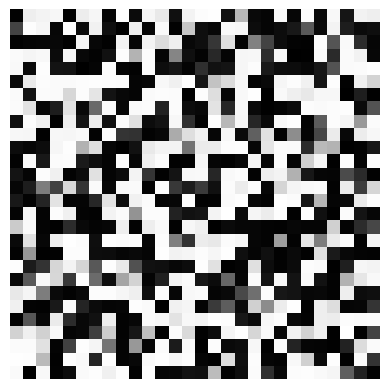

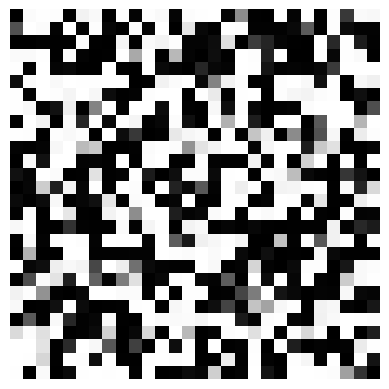

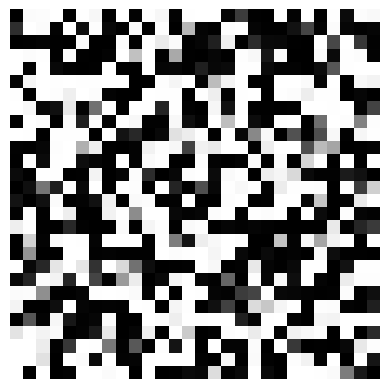

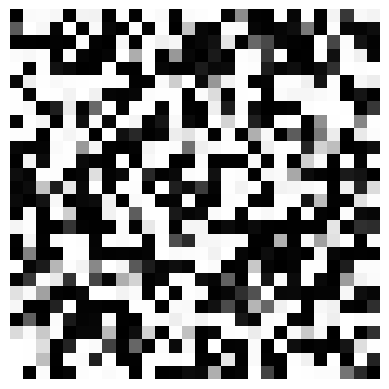

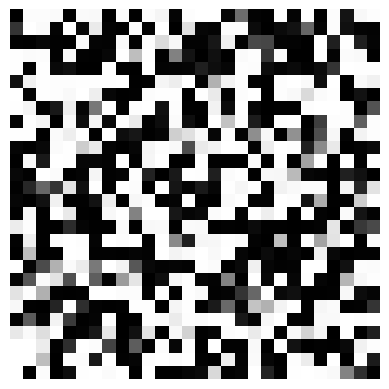

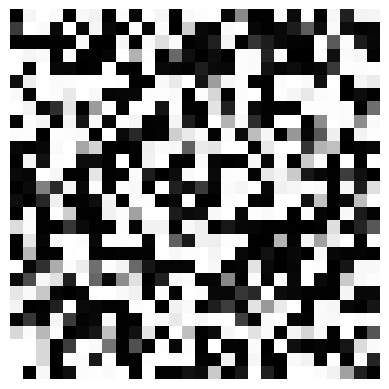

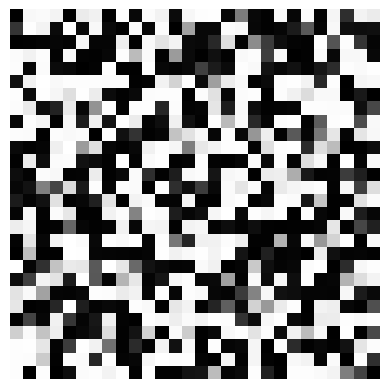

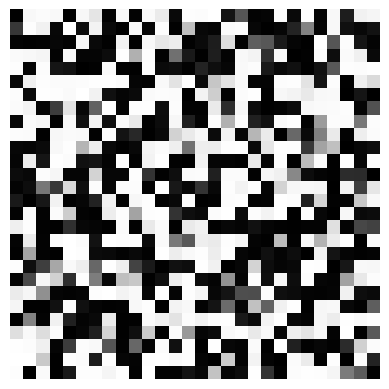

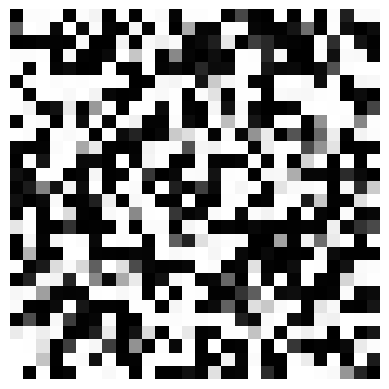

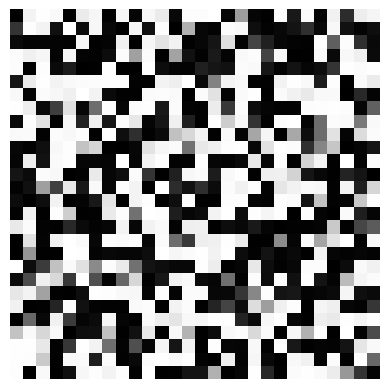

In [ ]:
noise = np.random.normal(
    0,
    1,
    (10, latent_dim)
)

generated_images = generator.predict(
    noise,
    verbose=0
)

generated_images = (
    generated_images + 1
) / 2.0

for i in range(10):

    plt.imshow(
        generated_images[i, :, :, 0],
        cmap="gray"
    )

    plt.axis("off")
    plt.show()
